In [1]:
!pip install -q "transformers<5.0.0" torch pandas openpyxl scikit-learn seaborn sentencepiece

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 19.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from transformers import pipeline
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Excel Dataset

In [3]:
from google.colab import files

uploaded = files.upload()

Saving Caribou-Juffair.csv to Caribou-Juffair.csv


In [4]:
import os

os.listdir('/content')

['.config', 'Caribou-Juffair.csv', 'sample_data']

In [23]:
import pandas as pd

data = pd.read_csv(
    '/content/Caribou-Juffair.csv',
    header=3
)

data.columns = data.columns.str.strip()

data.head()

,Review_ID,Review_Text,Sentiment,Topic,Evaluation_Rating,Language,Use_for_Zero_Shot,Source_Type,Source_URL
0,1,The iced latte was smooth and tasted fresh.,Positive,Drink Quality,5,English,Yes,Paraphrased evaluation sample,https://www.google.com/maps/place/Caribou+Coff...
1,2,"My cappuccino was warm, balanced, and not too ...",Positive,Drink Quality,5,English,Yes,Paraphrased evaluation sample,https://www.google.com/maps/place/Caribou+Coff...
2,3,"The coffee was okay, but nothing really stood ...",Neutral,Drink Quality,3,English,Yes,Paraphrased evaluation sample,https://www.google.com/maps/place/Caribou+Coff...
3,4,The drink tasted weaker than I expected.,Negative,Drink Quality,2,English,Yes,Paraphrased evaluation sample,https://www.google.com/maps/place/Caribou+Coff...
4,5,I liked the French press and would order it ag...,Positive,Drink Quality,5,English,Yes,Paraphrased evaluation sample,https://www.google.com/maps/place/Caribou+Coff...


In [24]:
data = data[['Review_Text']]

data = data.dropna()

data.head(10)

,Review_Text
0,The iced latte was smooth and tasted fresh.
1,"My cappuccino was warm, balanced, and not too ..."
2,"The coffee was okay, but nothing really stood ..."
3,The drink tasted weaker than I expected.
4,I liked the French press and would order it ag...
5,"The cooler looked good, although it was a litt..."
6,The barista was friendly and explained the dri...
7,Service was quick even though the cafe was busy.
8,"The staff were polite, but the order took long..."
9,My order was mixed up and I had to explain it ...


In [25]:
results = pipe(
    data['Review_Text'].astype(str).tolist(),
    truncation=True)

In [27]:
data['Predicted_Sentiment'] = [
    result['label'].capitalize()
    for result in results
]

data['Score'] = [
    result['score']
    for result in results
]

data['Metadata'] = 'huggingface_AI_model'

data.head(10)

,Review_Text,Predicted_Sentiment,Score,Metadata
0,The iced latte was smooth and tasted fresh.,Positive,0.833239,huggingface_AI_model
1,"My cappuccino was warm, balanced, and not too ...",Positive,0.598382,huggingface_AI_model
2,"The coffee was okay, but nothing really stood ...",Negative,0.587005,huggingface_AI_model
3,The drink tasted weaker than I expected.,Negative,0.782984,huggingface_AI_model
4,I liked the French press and would order it ag...,Positive,0.829759,huggingface_AI_model
5,"The cooler looked good, although it was a litt...",Negative,0.457738,huggingface_AI_model
6,The barista was friendly and explained the dri...,Positive,0.792164,huggingface_AI_model
7,Service was quick even though the cafe was busy.,Positive,0.408215,huggingface_AI_model
8,"The staff were polite, but the order took long...",Negative,0.451328,huggingface_AI_model
9,My order was mixed up and I had to explain it ...,Negative,0.713480,huggingface_AI_model


# Predicting reviews

In [28]:
data['Predicted_Sentiment'].value_counts()

,count
Predicted_Sentiment,
Positive,26
Neutral,18
Negative,16


# The upper part is a mini-practice ..

In [29]:
import pandas as pd

data = pd.read_csv(
    '/content/Caribou-Juffair.csv',
    header=3
)

data.columns = data.columns.str.strip()

data = data[['Review_Text', 'Sentiment']]

data = data.dropna()

data.head(10)

,Review_Text,Sentiment
0,The iced latte was smooth and tasted fresh.,Positive
1,"My cappuccino was warm, balanced, and not too ...",Positive
2,"The coffee was okay, but nothing really stood ...",Neutral
3,The drink tasted weaker than I expected.,Negative
4,I liked the French press and would order it ag...,Positive
5,"The cooler looked good, although it was a litt...",Neutral
6,The barista was friendly and explained the dri...,Positive
7,Service was quick even though the cafe was busy.,Positive
8,"The staff were polite, but the order took long...",Neutral
9,My order was mixed up and I had to explain it ...,Negative


In [31]:
results = pipe(
    data['Review_Text'].astype(str).tolist(),
    truncation=True)

In [32]:
data['Predicted_Sentiment'] = [
    result['label'].capitalize()
    for result in results
]

data['Score'] = [
    result['score']
    for result in results
]

data['Metadata'] = 'huggingface_AI_model'

data.head(10)

,Review_Text,Sentiment,Predicted_Sentiment,Score,Metadata
0,The iced latte was smooth and tasted fresh.,Positive,Positive,0.833239,huggingface_AI_model
1,"My cappuccino was warm, balanced, and not too ...",Positive,Positive,0.598382,huggingface_AI_model
2,"The coffee was okay, but nothing really stood ...",Neutral,Negative,0.587005,huggingface_AI_model
3,The drink tasted weaker than I expected.,Negative,Negative,0.782984,huggingface_AI_model
4,I liked the French press and would order it ag...,Positive,Positive,0.829759,huggingface_AI_model
5,"The cooler looked good, although it was a litt...",Neutral,Negative,0.457738,huggingface_AI_model
6,The barista was friendly and explained the dri...,Positive,Positive,0.792164,huggingface_AI_model
7,Service was quick even though the cafe was busy.,Positive,Positive,0.408215,huggingface_AI_model
8,"The staff were polite, but the order took long...",Neutral,Negative,0.451328,huggingface_AI_model
9,My order was mixed up and I had to explain it ...,Negative,Negative,0.713480,huggingface_AI_model


# Compare the correct and predicted answers

In [33]:
data[
    ['Review_Text', 'Sentiment', 'Predicted_Sentiment', 'Score']
].head(20)

,Review_Text,Sentiment,Predicted_Sentiment,Score
0,The iced latte was smooth and tasted fresh.,Positive,Positive,0.833239
1,"My cappuccino was warm, balanced, and not too ...",Positive,Positive,0.598382
2,"The coffee was okay, but nothing really stood ...",Neutral,Negative,0.587005
3,The drink tasted weaker than I expected.,Negative,Negative,0.782984
4,I liked the French press and would order it ag...,Positive,Positive,0.829759
5,"The cooler looked good, although it was a litt...",Neutral,Negative,0.457738
6,The barista was friendly and explained the dri...,Positive,Positive,0.792164
7,Service was quick even though the cafe was busy.,Positive,Positive,0.408215
8,"The staff were polite, but the order took long...",Neutral,Negative,0.451328
9,My order was mixed up and I had to explain it ...,Negative,Negative,0.713480


# Calculate accuracy

In [34]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    data['Sentiment'],
    data['Predicted_Sentiment']
)

accuracy

0.6833333333333333

# Calculate all evaluation metrics

In [36]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

precision = precision_score(
    data['Sentiment'],
    data['Predicted_Sentiment'],
    average='weighted',
    zero_division=0)

recall = recall_score(
    data['Sentiment'],
    data['Predicted_Sentiment'],
    average='weighted',
    zero_division=0)

f1 = f1_score(
    data['Sentiment'],
    data['Predicted_Sentiment'],
    average='weighted',
    zero_division=0)

accuracy, precision, recall, f1

(0.6833333333333333,
 0.6775641025641026,
 0.6833333333333333,
 0.6801978449037273)

In [37]:
model_results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Result': [accuracy, precision, recall, f1]
})

model_results

,Metric,Result
0,Accuracy,0.683333
1,Precision,0.677564
2,Recall,0.683333
3,F1 Score,0.680198


# Classification Report and Confusion Matrix

In [39]:
from sklearn.metrics import classification_report

best_model_name = 'Tutor XLM-RoBERTa'

best_predictions = data['Predicted_Sentiment']

print(best_model_name)

print(
    classification_report(
        data['Sentiment'],
        best_predictions,
        zero_division=0))

Tutor XLM-RoBERTa
              precision    recall  f1-score   support

    Negative       0.62      0.62      0.62        16
     Neutral       0.50      0.47      0.49        19
    Positive       0.85      0.88      0.86        25

    accuracy                           0.68        60
   macro avg       0.66      0.66      0.66        60
weighted avg       0.68      0.68      0.68        60



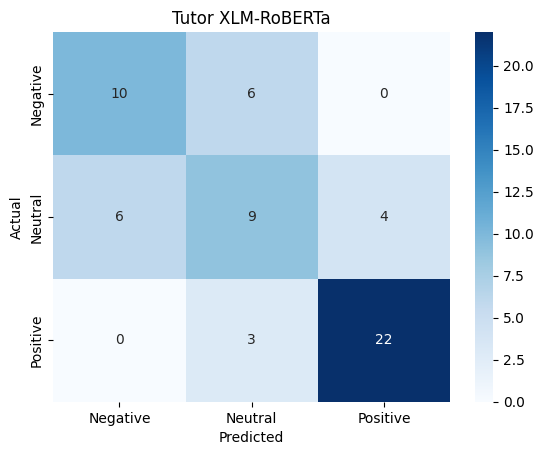

In [40]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

matrix = confusion_matrix(
    data['Sentiment'],
    best_predictions,
    labels=['Negative', 'Neutral', 'Positive']
)

sns.heatmap(
    matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Neutral', 'Positive'],
    yticklabels=['Negative', 'Neutral', 'Positive']
)

plt.title('Tutor XLM-RoBERTa')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Error analysis,

In [41]:
errors = data[
    data['Sentiment'] != data['Predicted_Sentiment']
].copy()

errors[
    ['Review_Text', 'Sentiment', 'Predicted_Sentiment', 'Score']
].head(10)

,Review_Text,Sentiment,Predicted_Sentiment,Score
2,"The coffee was okay, but nothing really stood ...",Neutral,Negative,0.587005
5,"The cooler looked good, although it was a litt...",Neutral,Negative,0.457738
8,"The staff were polite, but the order took long...",Neutral,Negative,0.451328
14,"The cafe was busy and lively, which may suit s...",Neutral,Positive,0.628260
17,"The music was fine, but the room felt crowded ...",Neutral,Negative,0.828623
18,The coffee was reasonably priced for the size.,Positive,Neutral,0.519154
21,I expected a larger drink for the amount I paid.,Negative,Neutral,0.673877
23,"The cake was nice, but the price felt a little...",Neutral,Negative,0.778049
27,A few tables still had empty cups when we arri...,Negative,Neutral,0.535585
30,The branch is easy to reach on Al Shabab Avenue.,Positive,Neutral,0.534657


# Define the three models

In [42]:
models = {'Tutor XLM-RoBERTa':
    'cardiffnlp/twitter-xlm-roberta-base-sentiment',

    'Multilingual DistilBERT':
    'lxyuan/distilbert-base-multilingual-cased-sentiments-student',

    'BERTweet':
    'finiteautomata/bertweet-base-sentiment-analysis'}

# Simple label-cleaning function

In [43]:
def clean_label(label):

    label = label.lower()

    if label in ['positive', 'pos', 'label_2']:
        return 'Positive'

    elif label in ['negative', 'neg', 'label_0']:
        return 'Negative'

    else:
        return 'Neutral'

# Evaluate all three models

In [44]:
import time
import pandas as pd

from transformers import pipeline
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [45]:
model_results = []
all_predictions = {}
all_scores = {}

for model_name, model_path in models.items():

    classifier = pipeline(
        'text-classification',
        model=model_path)

    predictions = []
    scores = []

    start = time.time()

    for review in data['Review_Text']:

        result = classifier(
            [str(review)],
            truncation=True)[0]

        predictions.append(
            clean_label(result['label']))

        scores.append(
            result['score'])

    total_time = time.time() - start

    all_predictions[model_name] = predictions
    all_scores[model_name] = scores

    model_results.append({
        'Model': model_name,
        'Accuracy': accuracy_score(
            data['Sentiment'],
            predictions),
        'Precision': precision_score(
            data['Sentiment'],
            predictions,
            average='weighted',
            zero_division=0),
        'Recall': recall_score(
            data['Sentiment'],
            predictions,
            average='weighted',
            zero_division=0),
        'F1 Score': f1_score(
            data['Sentiment'],
            predictions,
            average='weighted',
            zero_division=0),
        'Time': total_time})

Device set to use cpu
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


config.json:   0%|          | 0.00/759 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/541M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/373 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/22.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0
Device set to use cpu


# Display the comparison

In [46]:
results_df = pd.DataFrame(model_results)

results_df.sort_values(
    'F1 Score',
    ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,Time
2,BERTweet,0.766667,0.786111,0.766667,0.765769,18.675028
0,Tutor XLM-RoBERTa,0.683333,0.677564,0.683333,0.680198,6.245798
1,Multilingual DistilBERT,0.583333,0.574455,0.583333,0.555160,9.971204


In [47]:
best_model_name = results_df.sort_values(
    'F1 Score',
    ascending=False
).iloc[0]['Model']

best_predictions = all_predictions[best_model_name]

print(best_model_name)

print(
    classification_report(
        data['Sentiment'],
        best_predictions,
        zero_division=0
    )
)

BERTweet
              precision    recall  f1-score   support

    Negative       1.00      0.69      0.81        16
     Neutral       0.63      0.63      0.63        19
    Positive       0.77      0.92      0.84        25

    accuracy                           0.77        60
   macro avg       0.80      0.75      0.76        60
weighted avg       0.79      0.77      0.77        60



# Zero-Shot Classification

In [48]:
full_data = pd.read_csv(
    '/content/Caribou-Juffair.csv',
    header=3
)

full_data.columns = full_data.columns.str.strip()

full_data.head()

,Review_ID,Review_Text,Sentiment,Topic,Evaluation_Rating,Language,Use_for_Zero_Shot,Source_Type,Source_URL
0,1,The iced latte was smooth and tasted fresh.,Positive,Drink Quality,5,English,Yes,Paraphrased evaluation sample,https://www.google.com/maps/place/Caribou+Coff...
1,2,"My cappuccino was warm, balanced, and not too ...",Positive,Drink Quality,5,English,Yes,Paraphrased evaluation sample,https://www.google.com/maps/place/Caribou+Coff...
2,3,"The coffee was okay, but nothing really stood ...",Neutral,Drink Quality,3,English,Yes,Paraphrased evaluation sample,https://www.google.com/maps/place/Caribou+Coff...
3,4,The drink tasted weaker than I expected.,Negative,Drink Quality,2,English,Yes,Paraphrased evaluation sample,https://www.google.com/maps/place/Caribou+Coff...
4,5,I liked the French press and would order it ag...,Positive,Drink Quality,5,English,Yes,Paraphrased evaluation sample,https://www.google.com/maps/place/Caribou+Coff...


In [49]:
topic_data = full_data[
    full_data['Use_for_Zero_Shot'] == 'Yes'
].copy()

topic_data = topic_data[
    ['Review_Text', 'Topic']
].dropna()

topic_data.shape

(42, 2)

In [50]:
topic_data['Topic'].value_counts()

,count
Topic,
Drink Quality,6
Service,6
Atmosphere,6
Price,6
Cleanliness,6
Location,6
Waiting Time,6


# Define the candidate labels

In [52]:
candidate_labels = [
    'Drink Quality',
    'Service',
    'Atmosphere',
    'Price',
    'Cleanliness',
    'Location',
    'Waiting Time']

# Load the zero-shot model

In [53]:
zero_shot_model = pipeline(
    'zero-shot-classification',
    model='facebook/bart-large-mnli')

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cpu


# Test one review

In [54]:
test_result = zero_shot_model(
    'The latte tasted fresh and delicious.',
    candidate_labels,
    hypothesis_template='This coffee shop review is mainly about {}.')

test_result

{'sequence': 'The latte tasted fresh and delicious.',
 'labels': ['Drink Quality',
  'Cleanliness',
  'Atmosphere',
  'Price',
  'Location',
  'Waiting Time',
  'Service'],
 'scores': [0.37608423829078674,
  0.16915546357631683,
  0.13508397340774536,
  0.09895157068967819,
  0.08091016113758087,
  0.07721418887376785,
  0.06260041892528534]}

# Predict every review

In [55]:
topic_predictions = []
topic_scores = []
topic_outputs = []

for review in topic_data['Review_Text']:

    result = zero_shot_model(
        review,
        candidate_labels,
        hypothesis_template='This coffee shop review is mainly about {}.'
    )

    custom_result = {
        'label': result['labels'][0],
        'score': result['scores'][0],
        'metadata': 'huggingface_AI_model'
    }

    topic_outputs.append(custom_result)
    topic_predictions.append(custom_result['label'])
    topic_scores.append(custom_result['score'])

In [56]:
topic_outputs[:3]

[{'label': 'Drink Quality',
  'score': 0.3073784112930298,
  'metadata': 'huggingface_AI_model'},
 {'label': 'Drink Quality',
  'score': 0.25657758116722107,
  'metadata': 'huggingface_AI_model'},
 {'label': 'Atmosphere',
  'score': 0.2099938988685608,
  'metadata': 'huggingface_AI_model'}]

# Add the predictions

In [57]:
topic_data['Predicted_Topic'] = topic_predictions
topic_data['Score'] = topic_scores
topic_data['Metadata'] = 'huggingface_AI_model'

topic_data.head(10)

,Review_Text,Topic,Predicted_Topic,Score,Metadata
0,The iced latte was smooth and tasted fresh.,Drink Quality,Drink Quality,0.307378,huggingface_AI_model
1,"My cappuccino was warm, balanced, and not too ...",Drink Quality,Drink Quality,0.256578,huggingface_AI_model
2,"The coffee was okay, but nothing really stood ...",Drink Quality,Atmosphere,0.209994,huggingface_AI_model
3,The drink tasted weaker than I expected.,Drink Quality,Drink Quality,0.229718,huggingface_AI_model
4,I liked the French press and would order it ag...,Drink Quality,Drink Quality,0.348342,huggingface_AI_model
5,"The cooler looked good, although it was a litt...",Drink Quality,Drink Quality,0.226626,huggingface_AI_model
6,The barista was friendly and explained the dri...,Service,Service,0.363058,huggingface_AI_model
7,Service was quick even though the cafe was busy.,Service,Service,0.359377,huggingface_AI_model
8,"The staff were polite, but the order took long...",Service,Waiting Time,0.393164,huggingface_AI_model
9,My order was mixed up and I had to explain it ...,Service,Service,0.173387,huggingface_AI_model


# Calculate zero-shot accuracy and F1

In [58]:
topic_accuracy = accuracy_score(
    topic_data['Topic'],
    topic_data['Predicted_Topic'])


topic_f1 = f1_score(
    topic_data['Topic'],
    topic_data['Predicted_Topic'],
    average='weighted',
    zero_division=0)


topic_results = pd.DataFrame({
    'Metric': ['Accuracy', 'Weighted F1 Score'],
    'Result': [topic_accuracy, topic_f1]})


topic_results

,Metric,Result
0,Accuracy,0.738095
1,Weighted F1 Score,0.736239


# Investigate incorrect predictions

In [59]:
topic_errors = topic_data[
    topic_data['Topic'] != topic_data['Predicted_Topic']
].copy()

topic_errors[
    ['Review_Text', 'Topic', 'Predicted_Topic', 'Score']
].head(10)

,Review_Text,Topic,Predicted_Topic,Score
2,"The coffee was okay, but nothing really stood ...",Drink Quality,Atmosphere,0.209994
8,"The staff were polite, but the order took long...",Service,Waiting Time,0.393164
16,I enjoyed sitting outside in the evening.,Atmosphere,Location,0.340791
17,"The music was fine, but the room felt crowded ...",Atmosphere,Waiting Time,0.274507
21,I expected a larger drink for the amount I paid.,Price,Drink Quality,0.274726
22,The total bill was acceptable for two drinks a...,Price,Drink Quality,0.195303
27,A few tables still had empty cups when we arri...,Cleanliness,Service,0.196536
36,My takeaway order was ready in only a few minu...,Waiting Time,Service,0.262054
37,The queue moved quickly and I received my drin...,Waiting Time,Service,0.285058
38,"I waited around ten minutes, which was accepta...",Waiting Time,Service,0.194786


# Clear unused models

In [61]:
import gc
import torch

del zero_shot_model

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Clear unused models

In [62]:
summary_model = pipeline(
    'summarization',
    model='sshleifer/distilbart-cnn-12-6')

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

Device set to use cpu


# Create a longer Caribou review

In [63]:
long_review = """
The cafe has comfortable upstairs seating and free Wi-Fi,
so it was useful for studying. The staff were friendly and
my latte tasted good. However, the downstairs lights were
too bright and the order took longer than expected during
the busy evening.
"""

# Generate the summary

In [64]:
summary_result = summary_model(
    long_review,
    max_length=45,
    min_length=12,
    do_sample=False
)

summary_result

[{'summary_text': ' Cafe has comfortable upstairs seating and free Wi-Fi . Staff were friendly and my latte tasted good . However, downstairs lights were too bright and order took longer than expected .'}]

# Display it clearly

In [65]:
summary_text = summary_result[0]['summary_text']

print('Original review:')
print(long_review)

print('\nGenerated summary:')
print(summary_text)

Original review:

The cafe has comfortable upstairs seating and free Wi-Fi, 
so it was useful for studying. The staff were friendly and 
my latte tasted good. However, the downstairs lights were 
too bright and the order took longer than expected during 
the busy evening.


Generated summary:
 Cafe has comfortable upstairs seating and free Wi-Fi . Staff were friendly and my latte tasted good . However, downstairs lights were too bright and order took longer than expected .


# Evaluation

In [ ]:
summary_evaluation = pd.DataFrame({
    'Question': [
        'Is the summary understandable?',
        'Does it contain the main points?',
        'Is it shorter than the original review?'],
    'Answer': [
        'Yes',
        'Yes',
        'Yes']})

summary_evaluation

# Domain Shift

The sentiment models were originally trained on tweets and general sentiment datasets. They were not trained specifically on reviews from Caribou Coffee in Bahrain.

The Caribou reviews may contain coffee-related words, Bahrain locations, mixed opinions, spelling mistakes, Arabic, English, and a combination of both languages.

This difference between the model's original training data and my review dataset is called domain shift. Domain shift may cause the models to make incorrect predictions, especially for neutral reviews, local expressions, and reviews containing both positive and negative opinions.

# Model Limitations

The main limitations of this project are:

- The evaluation dataset contains only 60 reviews.

- Some reviews are short and do not provide much context.

- Sentiment can be subjective.

- A review may contain both positive and negative opinions.

- The models may struggle with Bahraini expressions and dialect.

- The zero-shot result can change when the candidate-label wording changes.

- The summarization model was trained mainly on news articles, not coffee-shop reviews.

- A high confidence score does not always mean the prediction is correct.

# Find the Winning Model

In [66]:
best_result = results_df.sort_values(
    'F1 Score',
    ascending=False).iloc[0]

best_result

,2
Model,BERTweet
Accuracy,0.766667
Precision,0.786111
Recall,0.766667
F1 Score,0.765769
Time,18.675028


In [67]:
best_model_name = best_result['Model']
best_accuracy = best_result['Accuracy']
best_f1 = best_result['F1 Score']

print('Best Model:', best_model_name)
print('Accuracy:', round(best_accuracy, 3))
print('F1 Score:', round(best_f1, 3))

Best Model: BERTweet
Accuracy: 0.767
F1 Score: 0.766


# Final Recommendation


I selected the best model based on its F1 score, accuracy, inference time, language support, and incorrect predictions.

The model with the highest F1 score is the most suitable model for this dataset. However, the largest model is not automatically the best choice. If two models have similar results, I would select the smaller or faster model because it would be easier to use in a Streamlit application.

The selected pretrained model can be used as a prototype. Before using it in a real business application, I would test it on more real reviews from Bahrain and include more Arabic and Bahraini-dialect examples.



# Decision: Use, Replace or Fine-Tune

I would use the best pretrained model for the first version of the application.

I would not train a model from scratch because the pretrained model already understands useful language patterns.

If the model continues making mistakes on Arabic, Bahraini dialect, coffee-related vocabulary, or mixed-language reviews, I would fine-tune it using a larger labeled dataset of Bahrain customer reviews.

# Reflection Questions

## Reflection Questions

### 1. What surprised you about the pretrained model?

I think it was surprising that the pretrained model could analyze new coffee-shop reviews without being trained by me.

### 2. What types of examples caused the most failures?

I think neutral reviews, mixed opinions, short reviews, local expressions, and indirect wording caused the most failures.

### 3. Did a larger or more popular model necessarily perform better?

I think a larger or more popular model did not necessarily perform better because the training data and domain were also important.

### 4. How important was the model's training data?

I think the training data was very important because it affected which languages, expressions, and writing styles the model understood.

### 5. What did you learn from the model card?

I think the model card helped me understand the task, architecture, training data, supported languages, license, intended use, and limitations.

### 6. What is the difference between a pretrained model and training from scratch?

I think a pretrained model has already learned useful patterns from a large dataset. Training from scratch would require much more data, computing power, and time.

### 7. When would fine-tuning be worth the additional effort?

I think fine-tuning would be useful if the model repeatedly failed on Arabic, Bahraini dialect, mixed-language reviews, or coffee-related vocabulary.

### 8. If you had ten times more data, what would you change?

I think I would include more English and Arabic reviews and divide the data into training, validation, and testing sets.

### 9. Would you deploy the model in a real application?

I think I would first use it as a support tool with human checking. I would not use it for fully automatic decisions until it had been tested on a larger real-world dataset.